In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

Tổng số mẫu trong file CSV: 5478
     filename  tom  jerry  class class_name
0  frame0.jpg    0      0      0    Neither
1  frame1.jpg    0      0      0    Neither
2  frame2.jpg    0      0      0    Neither
3  frame3.jpg    0      0      0    Neither
4  frame4.jpg    0      0      0    Neither
--------------------------------------------------
--- BƯỚC 1: Biểu đồ phân bố lớp ---


C:\Users\HP\AppData\Local\Temp\ipykernel_10128\3699095690.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class_name', order=['Neither', 'Jerry', 'Tom', 'Both'], palette='Set2')


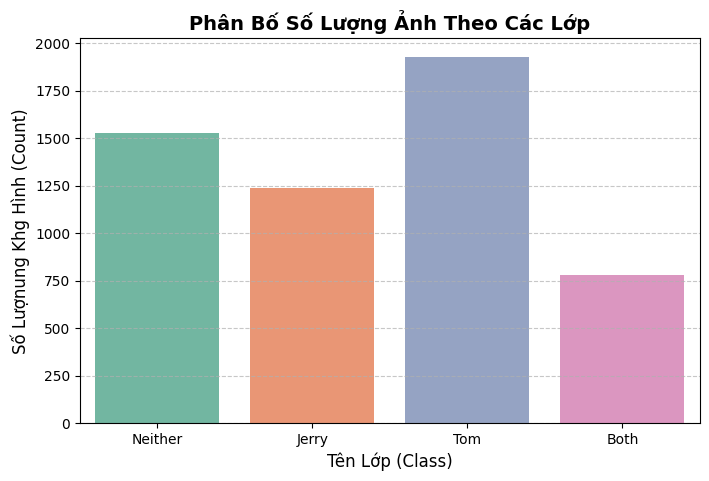

--- BƯỚC 2: Thống kê kích thước ảnh ---
Đang đọc kích thước ảnh...


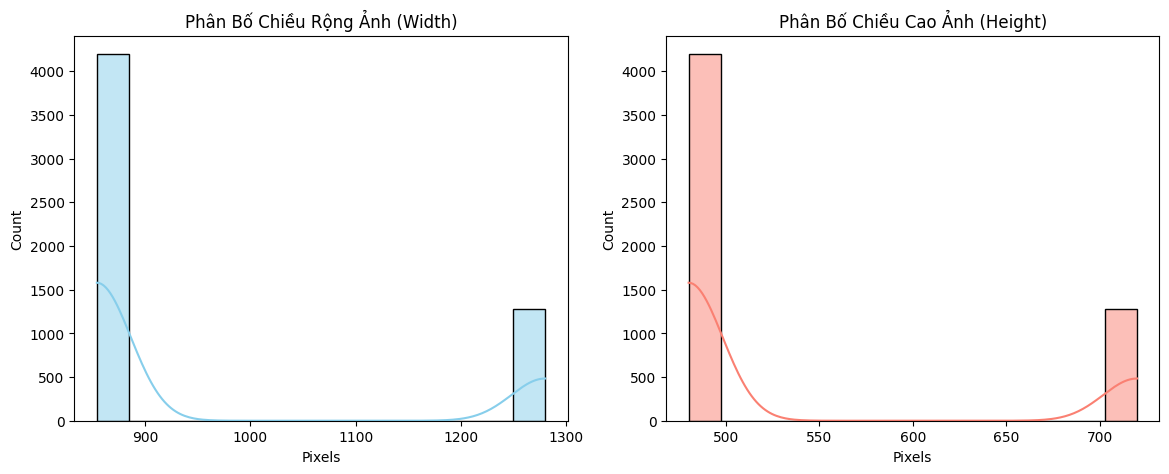

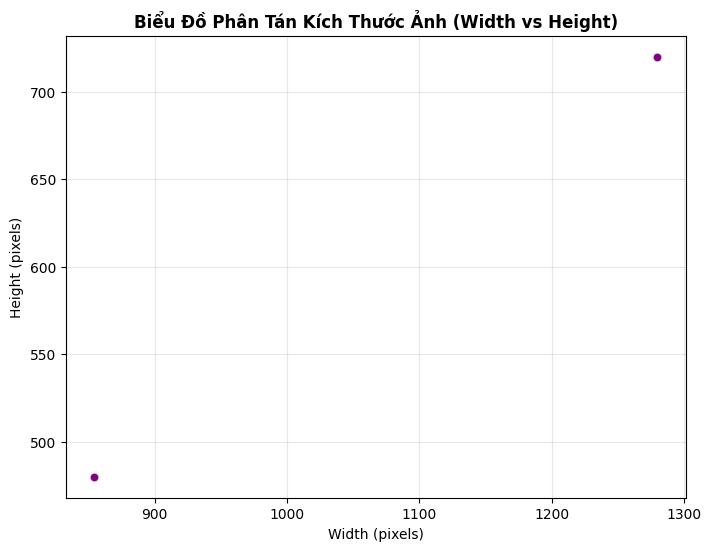

--- BƯỚC 3: Biểu đồ phân bố màu sắc ---


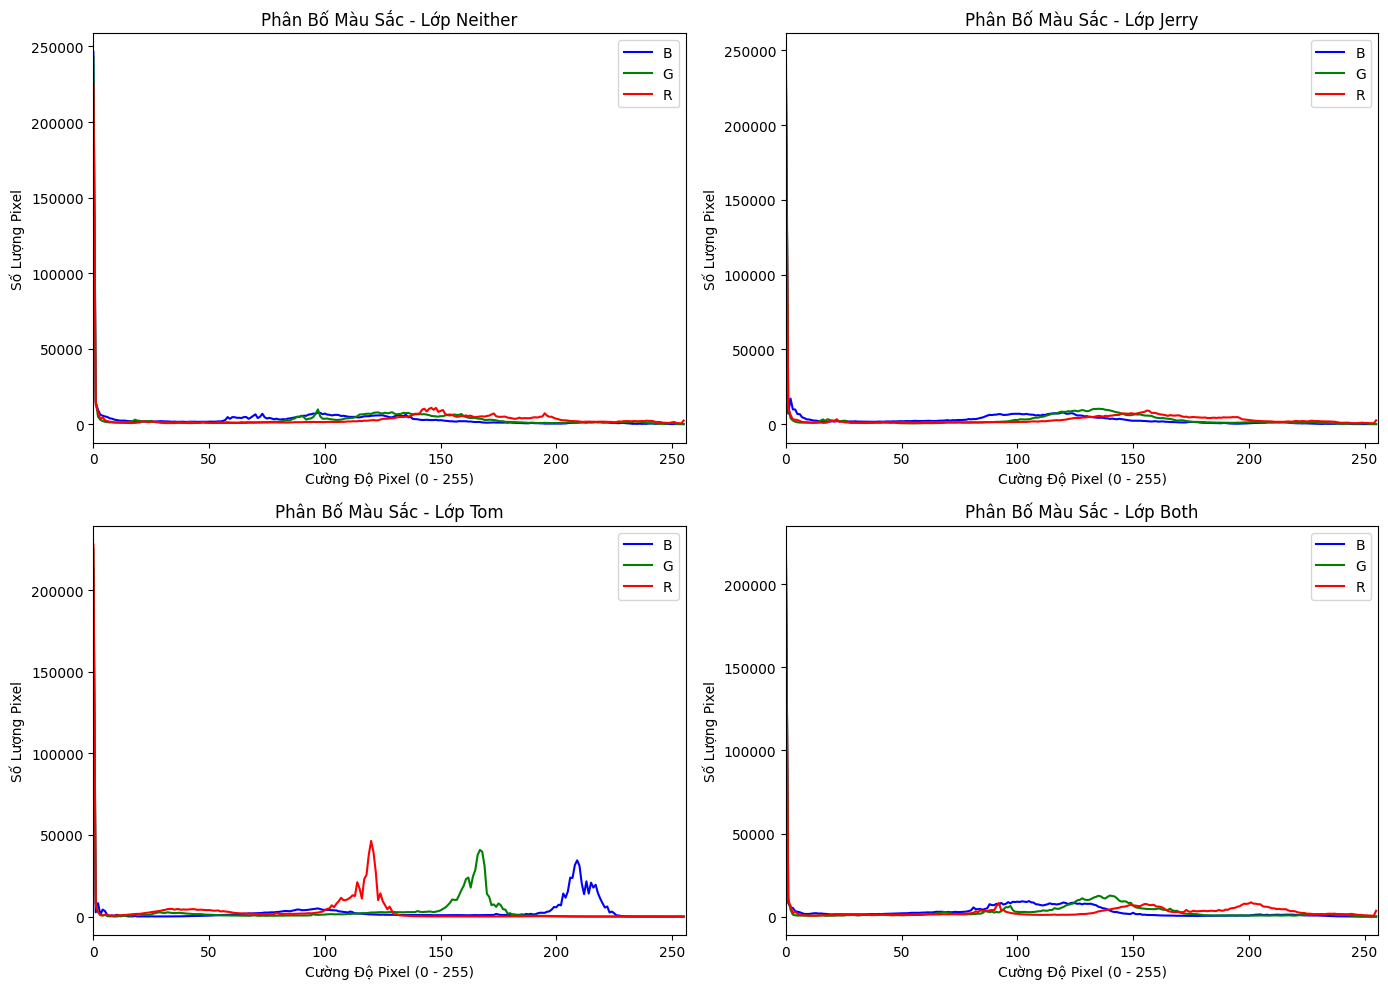

--- BƯỚC 4: Biểu đồ phân bố độ sáng ---
Đang tính toán độ sáng trung bình...


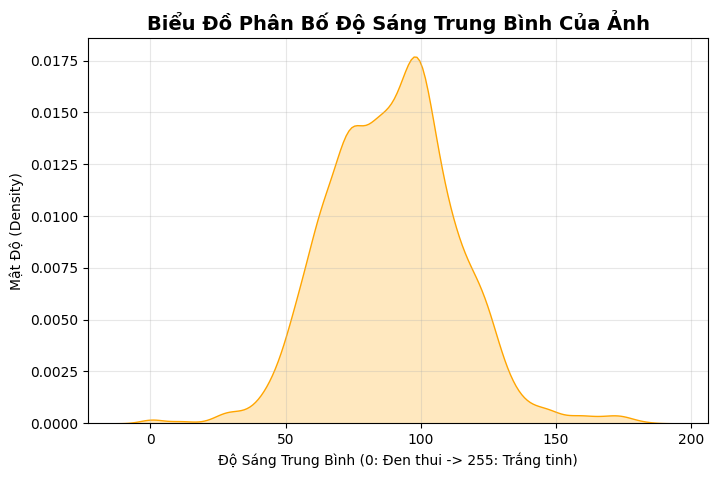

--- BƯỚC 5: Trực quan hóa lưới ảnh mẫu ---


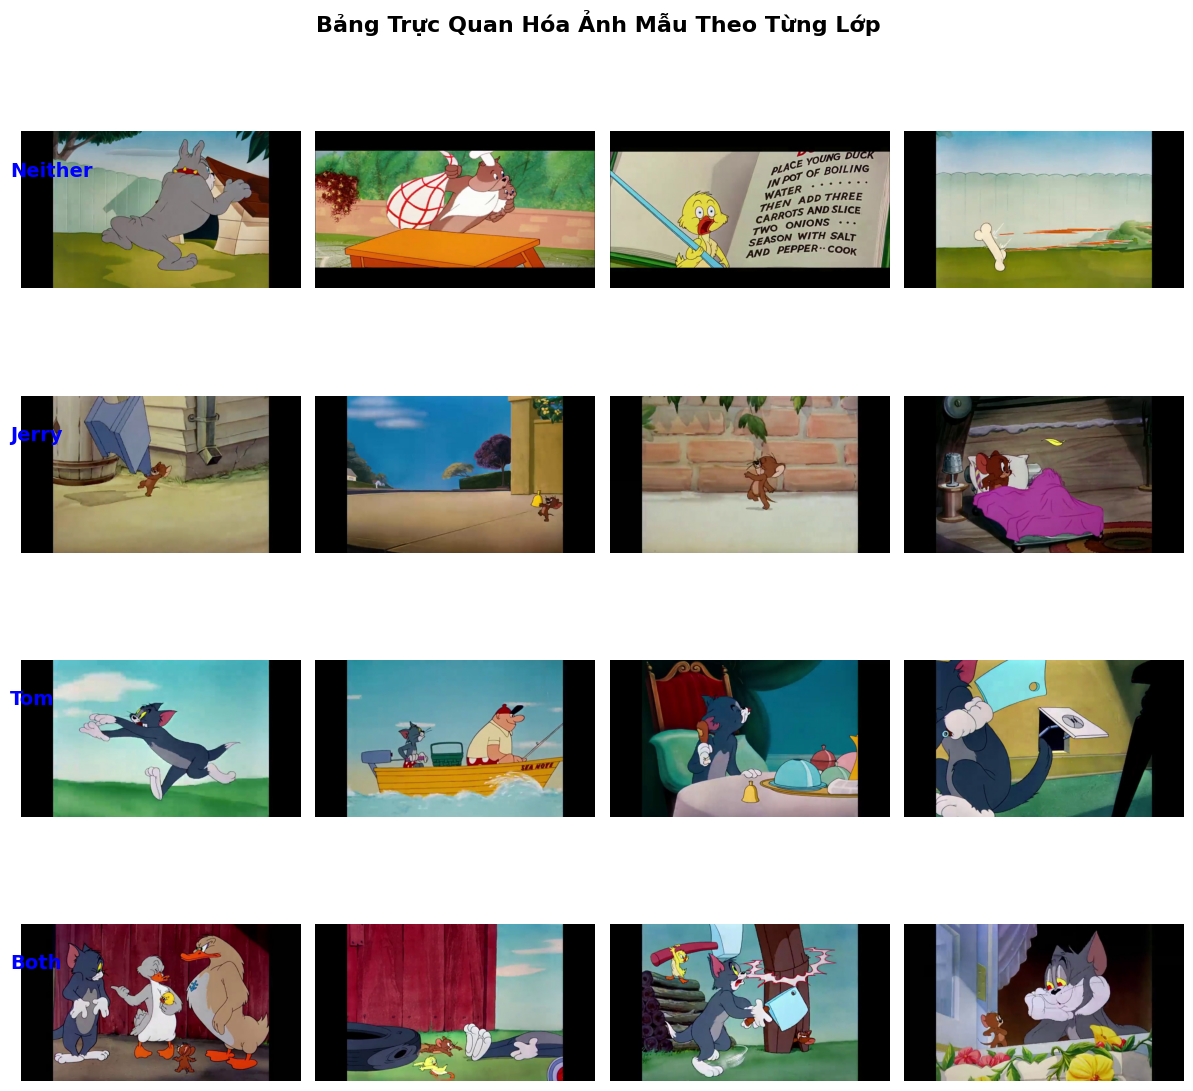

In [ ]:

DATA_ROOT = 'tom_and_jerry/tom_and_jerry/'

# Đọc file CSV
df = pd.read_csv('ground_truth.csv')

# XỬ LÝ GHÉP CỘT TOM VÀ JERRY THÀNH CỘT CLASS (0, 1, 2, 3)
def get_class_id(row):
    if row['tom'] == 0 and row['jerry'] == 0:
        return 0  # Neither
    elif row['tom'] == 0 and row['jerry'] == 1:
        return 1  # Jerry
    elif row['tom'] == 1 and row['jerry'] == 0:
        return 2  # Tom
    elif row['tom'] == 1 and row['jerry'] == 1:
        return 3  # Both

df['class'] = df.apply(get_class_id, axis=1)

class_names = {0: 'Neither', 1: 'Jerry', 2: 'Tom', 3: 'Both'}
df['class_name'] = df['class'].map(class_names)

print(f"Tổng số mẫu trong file CSV: {len(df)}")
print(df.head())
print("-" * 50)

# Hàm hỗ trợ tìm đường dẫn file ảnh chính xác
def find_image_path(filename):
    p1 = os.path.join(DATA_ROOT, filename)
    if os.path.exists(p1):
        return p1

    for folder in ['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1']:
        p2 = os.path.join(DATA_ROOT, folder, filename)
        if os.path.exists(p2):
            return p2

    matches = glob.glob(DATA_ROOT + '/**/' + filename, recursive=True)
    if matches:
        return matches[0]

    return None


# 1. PHÂN BỐ CÁC LỚP (CLASS DISTRIBUTION)
def plot_class_distribution(df):
    plt.figure(figsize=(8, 5))

    sns.countplot(data=df, x='class_name', order=['Neither', 'Jerry', 'Tom', 'Both'], palette='Set2')

    plt.title('Phân Bố Số Lượng Ảnh Theo Các Lớp', fontsize=14, fontweight='bold')
    plt.xlabel('Tên Lớp (Class)', fontsize=12)
    plt.ylabel('Số Lượnung Khg Hình (Count)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

print("--- BƯỚC 1: Biểu đồ phân bố lớp ---")
plot_class_distribution(df)


# 2. THỐNG KÊ KÍCH THƯỚC ẢNH (DIMENSIONS)
def plot_image_dimensions(df):
    widths = []
    heights = []

    print("Đang đọc kích thước ảnh...")
    for filename in df['filename']:
        img_path = find_image_path(filename)
        if img_path:
            img = cv2.imread(img_path)
            if img is not None:
                h, w, _ = img.shape
                widths.append(w)
                heights.append(h)

    df_dim = pd.DataFrame({'width': widths, 'height': heights})

    # 1. Histogram Width & Height
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df_dim['width'], ax=axes[0], color='skyblue', kde=True)
    axes[0].set_title('Phân Bố Chiều Rộng Ảnh (Width)')
    axes[0].set_xlabel('Pixels')

    sns.histplot(df_dim['height'], ax=axes[1], color='salmon', kde=True)
    axes[1].set_title('Phân Bố Chiều Cao Ảnh (Height)')
    axes[1].set_xlabel('Pixels')
    plt.show()

    # 2. Scatter Plot Width vs Height
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_dim, x='width', y='height', color='purple', alpha=0.6)
    plt.title('Biểu Đồ Phân Tán Kích Thước Ảnh (Width vs Height)', fontsize=12, fontweight='bold')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Height (pixels)')
    plt.grid(True, alpha=0.3)
    plt.show()

print("--- BƯỚC 2: Thống kê kích thước ảnh ---")
plot_image_dimensions(df)


 
# 3. PHÂN BỐ MÀU SẮC (COLOR HISTOGRAMS)
def plot_color_histograms(df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    channels = ('b', 'g', 'r') # OpenCV mặc định là BGR

    for idx, (c_id, c_name) in enumerate(class_names.items()):
        class_rows = df[df['class'] == c_id]
        if len(class_rows) == 0:
            continue

        sample_file = class_rows['filename'].iloc[0]
        img_path = find_image_path(sample_file)

        if img_path:
            img = cv2.imread(img_path)
            if img is not None:
                for i, color in enumerate(channels):
                    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
                    axes[idx].plot(hist, color=color, label=color.upper())

                axes[idx].set_title(f'Phân Bố Màu Sắc - Lớp {c_name}')
                axes[idx].set_xlim([0, 256])
                axes[idx].set_xlabel('Cường Độ Pixel (0 - 255)')
                axes[idx].set_ylabel('Số Lượng Pixel')
                axes[idx].legend()

    plt.tight_layout()
    plt.show()

print("--- BƯỚC 3: Biểu đồ phân bố màu sắc ---")
plot_color_histograms(df)


# 4. THỐNG KÊ ĐỘ SÁNG TRUNG BÌNH (BRIGHTNESS)
def plot_brightness_distribution(df):
    brightness_values = []

    print("Đang tính toán độ sáng trung bình...")
    for filename in df['filename']:
        img_path = find_image_path(filename)
        if img_path:
            img = cv2.imread(img_path)
            if img is not None:
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                brightness_values.append(np.mean(gray))

    plt.figure(figsize=(8, 5))
    sns.kdeplot(brightness_values, fill=True, color='orange')
    plt.title('Biểu Đồ Phân Bố Độ Sáng Trung Bình Của Ảnh', fontsize=14, fontweight='bold')
    plt.xlabel('Độ Sáng Trung Bình (0: Đen thui -> 255: Trắng tinh)')
    plt.ylabel('Mật Độ (Density)')
    plt.grid(True, alpha=0.3)
    plt.show()

print("--- BƯỚC 4: Biểu đồ phân bố độ sáng ---")
plot_brightness_distribution(df)


# 5. TRỰC QUAN HÓA LƯỚI ẢNH MẪU (IMAGE GRID)
def plot_image_grid(df):
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))

    for row_idx, (c_id, c_name) in enumerate(class_names.items()):
        class_rows = df[df['class'] == c_id]
        if len(class_rows) < 4:
            continue

        samples = class_rows.sample(4, random_state=42)['filename'].values

        for col_idx, filename in enumerate(samples):
            img_path = find_image_path(filename)
            ax = axes[row_idx, col_idx]

            if img_path:
                img = cv2.imread(img_path)
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    ax.imshow(img_rgb)

            ax.axis('off')

            if col_idx == 0:
                ax.text(-35, 120, c_name, rotation=0,
                        verticalalignment='center', fontsize=14, fontweight='bold', color='blue')

    plt.suptitle('Bảng Trực Quan Hóa Ảnh Mẫu Theo Từng Lớp', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("--- BƯỚC 5: Trực quan hóa lưới ảnh mẫu ---")
plot_image_grid(df)

In [3]:
DATA_ROOT = 'tom_and_jerry/tom_and_jerry/'
TRAIN_JERRY_DIR = DATA_ROOT + 'jerry/'
TRAIN_TOM_DIR   = DATA_ROOT + 'tom/'
CHALLENGE_0_DIR = DATA_ROOT + 'tom_jerry_0/'
CHALLENGE_1_DIR = DATA_ROOT + 'tom_jerry_1/'
CHALLENGES_CSV   = 'challenges.csv'
SUBMISSION_PATH  = 'submission.csv'


In [ ]:

# 1. TIỀN XỬ LÝ ẢNH
def preprocess_single_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    if img is None:
        return np.zeros((target_size[0], target_size[1], 3), dtype=np.float32)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        img = img[y:y+h, x:x+w]

    h, w = img.shape[:2]
    if h > w:
        pad = (h - w) // 2
        img_padded = cv2.copyMakeBorder(img, 0, 0, pad, pad, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    else:
        pad = (w - h) // 2
        img_padded = cv2.copyMakeBorder(img, pad, pad, 0, 0, cv2.BORDER_CONSTANT, value=[0, 0, 0])

    img_resized = cv2.resize(img_padded, target_size)
    return img_resized.astype(np.float32) / 255.0


# HÀM TRÍCH XUẤT ĐẶC TRƯNG THEO TỪNG BATCH CHO TẬP TRAIN
def extract_features_in_batches(folder_path, label, base_model, batch_size=64):
    features = []
    labels = []
    batch_images = []

    file_list = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    total_files = len(file_list)

    print(f"Đang xử lý thư mục: {folder_path} ({total_files} ảnh)...")

    for idx, fname in enumerate(file_list):
        img_path = os.path.join(folder_path, fname)
        img = preprocess_single_image(img_path)
        batch_images.append(img)
        labels.append(label)

        if len(batch_images) == batch_size or idx == total_files - 1:
            batch_arr = np.array(batch_images, dtype=np.float32)
            batch_feats = base_model.predict(batch_arr, verbose=0)
            features.extend(batch_feats)

            batch_images = []

        if (idx + 1) % 500 == 0:
            print(f"  > Đã trích xuất {idx + 1}/{total_files} ảnh")

    return features, labels


# HÀM TRÍCH XUẤT ĐẶC TRƯNG THEO TỪNG BATCH CHO TẬP CHALLENGE
def extract_challenge_features_in_batches(df, base_model, batch_size=64):
    features = []
    batch_images = []
    total_files = len(df)

    print(f"Đang trích xuất đặc trưng cho {total_files} ảnh Challenge...")

    for idx, row in df.iterrows():
        folder_name = row['folder']
        image_name = row['image_name']
        img_path = os.path.join(DATA_ROOT, folder_name, image_name)

        img = preprocess_single_image(img_path)
        batch_images.append(img)

        if len(batch_images) == batch_size or idx == total_files - 1:
            batch_arr = np.array(batch_images, dtype=np.float32)
            batch_feats = base_model.predict(batch_arr, verbose=0)
            features.extend(batch_feats)
            batch_images = []

        if (idx + 1) % 500 == 0:
            print(f"  > Đã trích xuất {idx + 1}/{total_files} ảnh")

    return np.array(features)



# 2. BƯỚC THỰC THI CHÍNH (MAIN PIPELINE)
print("--- KHỞI TẠO MODEL MOBILENETV2 ---")
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

print("\n--- BƯỚC 1 & 2: TRÍCH XUẤT ĐẶC TRƯNG TRỰC TIẾP ---")
neither_feats, neither_labels = extract_features_in_batches(CHALLENGE_0_DIR, 0, base_model)
jerry_feats, jerry_labels = extract_features_in_batches(TRAIN_JERRY_DIR, 1, base_model)
tom_feats, tom_labels = extract_features_in_batches(TRAIN_TOM_DIR, 2, base_model)
both_feats, both_labels = extract_features_in_batches(CHALLENGE_1_DIR, 3, base_model)


# Gộp các đặc trưng nhẹ lại
X_train_features = np.vstack([neither_feats, jerry_feats, tom_feats, both_feats])
y_train = np.array(neither_labels + jerry_labels + tom_labels + both_labels)
print(f"Thành công! Kích thước ma trận đặc trưng tập train: {X_train_features.shape}")
print(f"Phân bố nhãn học được: {np.bincount(y_train)}")



print("\n--- BƯỚC 3: HUẤN LUYỆN PIPELINE PCA + SVM W/ GRIDSEARCH ---")
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(kernel='rbf', decision_function_shape='ovo'))
])

param_grid = {
    'svm__C': [0.1, 1.0, 10.0],
    'svm__gamma': ['scale']
}

grid_search = GridSearchCV(svm_pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_features, y_train)
print(f"Mô hình tốt nhất tìm được: {grid_search.best_params_}")


print("\n--- BƯỚC 4: DỰ ĐOÁN TRÊN TẬP CHALLENGES (AN TOÀN BỘ NHỚ) ---")
challenge_df = pd.read_csv(CHALLENGES_CSV)

# Trích xuất đặc trưng tập thách thức dạng Batch
X_challenge_features = extract_challenge_features_in_batches(challenge_df, base_model)

# Dự đoán nhãn
y_pred_encoded = grid_search.predict(X_challenge_features)


print("\n--- BƯỚC 5: XUẤT FILE SUBMISSION ---")
def decode_predictions(predictions):
    decoded = []
    for pred in predictions:
        if pred == 3:
            decoded.append([1, 1])
        elif pred == 1:
            decoded.append([0, 1])  # Jerry
        elif pred == 2:
            decoded.append([1, 0])  # Tom
        else:
            decoded.append([0, 0])  # Neither
    return pd.DataFrame(decoded, columns=['tom', 'jerry'])

df_decoded = decode_predictions(y_pred_encoded)

submission_df = pd.DataFrame()
submission_df['image_name'] = challenge_df['image_name']
submission_df['tom'] = df_decoded['tom']
submission_df['jerry'] = df_decoded['jerry']

submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f"Đã xuất thành công kết quả không lỗi RAM ra file: {SUBMISSION_PATH}")

--- KHỞI TẠO MODEL MOBILENETV2 ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

--- BƯỚC 1 & 2: TRÍCH XUẤT ĐẶC TRƯNG TRỰC TIẾP (AN TOÀN BỘ NHỚ) ---
Đang xử lý thư mục: tom_and_jerry/tom_and_jerry/tom_jerry_0/ (1528 ảnh)...
  > Đã trích xuất 500/1528 ảnh
  > Đã trích xuất 1000/1528 ảnh
  > Đã trích xuất 1500/1528 ảnh
Đang xử lý thư mục: tom_and_jerry/tom_and_jerry/jerry/ (1240 ảnh)...
  > Đã trích xuất 500/1240 ảnh
  > Đã trích xuất 1000/1240 ảnh
Đang xử lý thư mục: tom_and_jerry/tom_and_jerry/tom/ (1930 ảnh)...
  > Đã trích xuất 500/1930 ảnh
  > Đã trích xuất 1000/1930 ảnh
  > Đã trích xuất 1500/1930 ảnh
Đang xử lý thư mục: tom_and_jerry/tom_and_jerry/tom_jerry_1/ (780 ảnh)...
  > Đã trích xuất 500/780 ảnh
Thành công! Kích thước ma trận đặc trưng tập train: (5478, 1280)
Phân bố nhãn học được: [1528 1240 1930  780]

--- BƯỚC 3: HUẤN LUYỆN PIPELINE PCA + SVM W/ GRIDSEARCH ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mô hình tốt nhất tìm được: {'svm__C': 10.0, 'svm_